In [5]:
import pandas as pd

df = pd.read_csv('/content/delivery_data.csv')
display(df.head())

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [8]:
datetime_columns = [
    'trip_creation_time', 'od_start_time', 'od_end_time', 'cutoff_timestamp'
]

for col in datetime_columns:
    df[col] = pd.to_datetime(df[col], format='mixed')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   data                            144867 non-null  object        
 1   trip_creation_time              144867 non-null  datetime64[ns]
 2   route_schedule_uuid             144867 non-null  object        
 3   route_type                      144867 non-null  object        
 4   trip_uuid                       144867 non-null  object        
 5   source_center                   144867 non-null  object        
 6   source_name                     144574 non-null  object        
 7   destination_center              144867 non-null  object        
 8   destination_name                144606 non-null  object        
 9   od_start_time                   144867 non-null  datetime64[ns]
 10  od_end_time                     144867 non-null  datetim

In [9]:
print(df.isnull().sum())

data                                0
trip_creation_time                  0
route_schedule_uuid                 0
route_type                          0
trip_uuid                           0
source_center                       0
source_name                       293
destination_center                  0
destination_name                  261
od_start_time                       0
od_end_time                         0
start_scan_to_end_scan              0
is_cutoff                           0
cutoff_factor                       0
cutoff_timestamp                    0
actual_distance_to_destination      0
actual_time                         0
osrm_time                           0
osrm_distance                       0
factor                              0
segment_actual_time                 0
segment_osrm_time                   0
segment_osrm_distance               0
segment_factor                      0
dtype: int64


In [10]:
def get_time_band(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['od_start_hour'] = df['od_start_time'].dt.hour
df['od_start_time_band'] = df['od_start_hour'].apply(get_time_band)

display(df[['od_start_time', 'od_start_hour', 'od_start_time_band']].head())

,od_start_time,od_start_hour,od_start_time_band
0,2018-09-20 03:21:32.418600,3,Night
1,2018-09-20 03:21:32.418600,3,Night
2,2018-09-20 03:21:32.418600,3,Night
3,2018-09-20 03:21:32.418600,3,Night
4,2018-09-20 03:21:32.418600,3,Night


In [11]:
# Calculate actual delivery duration from od_start_time to od_end_time
df['actual_delivery_duration_calculated'] = (df['od_end_time'] - df['od_start_time']).dt.total_seconds() / 3600  # in hours

# Check if 'actual_time' column exists to calculate delay
if 'actual_time' in df.columns:
    # Assuming 'actual_time' is the expected delivery time in hours
    df['delay_in_hours'] = df['actual_delivery_duration_calculated'] - df['actual_time']
    df['delay_ratio'] = df['delay_in_hours'] / df['actual_time']
    print("Delay calculated based on 'actual_time' column.")
else:
    print("No 'actual_time' column found. Using 'actual_delivery_duration_calculated' as time taken for delivery.")
    df['time_taken_to_deliver_hours'] = df['actual_delivery_duration_calculated']

# Display relevant columns to show the calculated delay/time taken
display(df[['od_start_time', 'od_end_time', 'actual_delivery_duration_calculated', 'actual_time', 'delay_in_hours', 'delay_ratio']].head())

Delay calculated based on 'actual_time' column.


,od_start_time,od_end_time,actual_delivery_duration_calculated,actual_time,delay_in_hours,delay_ratio
0,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,1.436894,14.0,-12.563106,-0.897365
1,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,1.436894,24.0,-22.563106,-0.940129
2,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,1.436894,40.0,-38.563106,-0.964078
3,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,1.436894,62.0,-60.563106,-0.976824
4,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,1.436894,68.0,-66.563106,-0.978869


In [12]:
import networkx as nx

G = nx.DiGraph() # Using a directed graph as routes have a source and destination

In [13]:
# Add nodes (facilities)
# Collect all unique source and destination centers
all_centers = pd.concat([df['source_center'], df['destination_center']]).unique()

for center in all_centers:
    G.add_node(center)

print(f"Number of nodes added: {G.number_of_nodes()}")

Number of nodes added: 1657


In [14]:
# Add edges (routes) with attributes
# Iterate through the DataFrame to add edges
for index, row in df.iterrows():
    source = row['source_center']
    destination = row['destination_center']

    # Add edge with relevant attributes
    G.add_edge(
        source, destination,
        trip_uuid=row['trip_uuid'],
        route_type=row['route_type'],
        actual_distance_to_destination=row['actual_distance_to_destination'],
        actual_time=row['actual_time'],
        osrm_time=row['osrm_time'],
        osrm_distance=row['osrm_distance'],
        delay_in_hours=row.get('delay_in_hours', None), # Use .get to handle cases where it might not exist
        delay_ratio=row.get('delay_ratio', None)
    )

In [15]:
print(f"Total number of nodes in the graph: {G.number_of_nodes()}")
print(f"Total number of edges in the graph: {G.number_of_edges()}")

# Display a few nodes
print("\nSample nodes:")
for i, node in enumerate(list(G.nodes())[:5]):
    print(f"- {node}")

# Display a few edges and their attributes
print("\nSample edges with attributes:")
for i, (u, v, data) in enumerate(list(G.edges(data=True))[:5]):
    print(f"- Edge from {u} to {v} with attributes: {data}")

Total number of nodes in the graph: 1657
Total number of edges in the graph: 2783

Sample nodes:
- IND388121AAA
- IND388620AAB
- IND421302AAG
- IND400011AAA
- IND562132AAA

Sample edges with attributes:
- Edge from IND388121AAA to IND388620AAB with attributes: {'trip_uuid': 'trip-153801468900715290', 'route_type': 'Carting', 'actual_distance_to_destination': 42.51208604614448, 'actual_time': 93.0, 'osrm_time': 41.0, 'osrm_distance': 51.2163, 'delay_in_hours': -91.23922809805556, 'delay_ratio': -0.9810669687962964}
- Edge from IND388620AAB to IND388320AAA with attributes: {'trip_uuid': 'trip-153801468900715290', 'route_type': 'Carting', 'actual_distance_to_destination': 41.91451780120824, 'actual_time': 90.0, 'osrm_time': 41.0, 'osrm_distance': 50.6927, 'delay_in_hours': -87.84266254027777, 'delay_ratio': -0.9760295837808641}
- Edge from IND421302AAG to IND411033AAA with attributes: {'trip_uuid': 'trip-153761584139918815', 'route_type': 'FTL', 'actual_distance_to_destination': 100.56207

In [16]:
# Calculate Betweenness Centrality
betweenness_centrality = nx.betweenness_centrality(G)

# Convert to DataFrame for easier analysis and sorting
betweenness_df = pd.DataFrame(betweenness_centrality.items(), columns=['Node', 'Betweenness_Centrality'])

display(betweenness_df.head())

,Node,Betweenness_Centrality
0,IND388121AAA,0.000405
1,IND388620AAB,0.000403
2,IND421302AAG,0.069625
3,IND400011AAA,0.000808
4,IND562132AAA,0.124943


In [17]:
# Calculate In-Degree Centrality
in_degree_centrality = G.in_degree()
in_degree_df = pd.DataFrame(in_degree_centrality, columns=['Node', 'In_Degree_Centrality'])

# Calculate Out-Degree Centrality
out_degree_centrality = G.out_degree()
out_degree_df = pd.DataFrame(out_degree_centrality, columns=['Node', 'Out_Degree_Centrality'])

# Merge degree centralities into a single DataFrame
degree_df = pd.merge(in_degree_df, out_degree_df, on='Node')

display(degree_df.head())

,Node,In_Degree_Centrality,Out_Degree_Centrality
0,IND388121AAA,1,1
1,IND388620AAB,1,1
2,IND421302AAG,29,29
3,IND400011AAA,2,2
4,IND562132AAA,36,35


In [18]:
# Identify top 5 bottleneck hubs based on Betweenness Centrality
top_5_bottleneck_hubs = betweenness_df.sort_values(by='Betweenness_Centrality', ascending=False).head(5)

print("Top 5 Bottleneck Hubs (by Betweenness Centrality):")
display(top_5_bottleneck_hubs)

Top 5 Bottleneck Hubs (by Betweenness Centrality):


,Node,Betweenness_Centrality
32,IND000000ACB,0.220228
4,IND562132AAA,0.124943
111,IND501359AAE,0.092632
94,IND712311AAA,0.090659
2,IND421302AAG,0.069625


In [31]:
bottleneck_nodes = top_5_bottleneck_hubs['Node'].tolist()

routes_through_bottlenecks = 0
for u, v in G.edges():
    if u in bottleneck_nodes or v in bottleneck_nodes:
        routes_through_bottlenecks += 1

print(f"\nNumber of routes passing through the top 5 bottleneck hubs: {routes_through_bottlenecks}")


Number of routes passing through the top 5 bottleneck hubs: 309


In [19]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Ensure 'od_start_time' is datetime (already done in preprocessing)

# Extract hour and day of week from od_start_time
df['day_of_week'] = df['od_start_time'].dt.dayofweek # Monday=0, Sunday=6

# Select features and target
features = ['osrm_time', 'route_type', 'od_start_hour', 'day_of_week']
target = 'actual_delivery_duration_calculated'

X = df[features]
y = df[target]

display(X.head())

,osrm_time,route_type,od_start_hour,day_of_week
0,11.0,Carting,3,3
1,20.0,Carting,3,3
2,28.0,Carting,3,3
3,40.0,Carting,3,3
4,44.0,Carting,3,3


In [20]:
# Define categorical and numerical features
categorical_features = ['route_type']
numerical_features = ['osrm_time', 'od_start_hour', 'day_of_week']

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ])

# Display the preprocessor (optional, for verification)
display(preprocessor)

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['route_type']),
                                ('num', 'passthrough',
                                 ['osrm_time', 'od_start_hour',
                                  'day_of_week'])])

In [21]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (115893, 4)
Testing data shape: (28974, 4)


In [22]:
# Create a pipeline with preprocessing and model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# Train the model
print("Training the model...")
model.fit(X_train, y_train)
print("Model training complete.")

Training the model...
Model training complete.


In [23]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model using Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.4f} hours")

Mean Absolute Error (MAE): 6.1311 hours


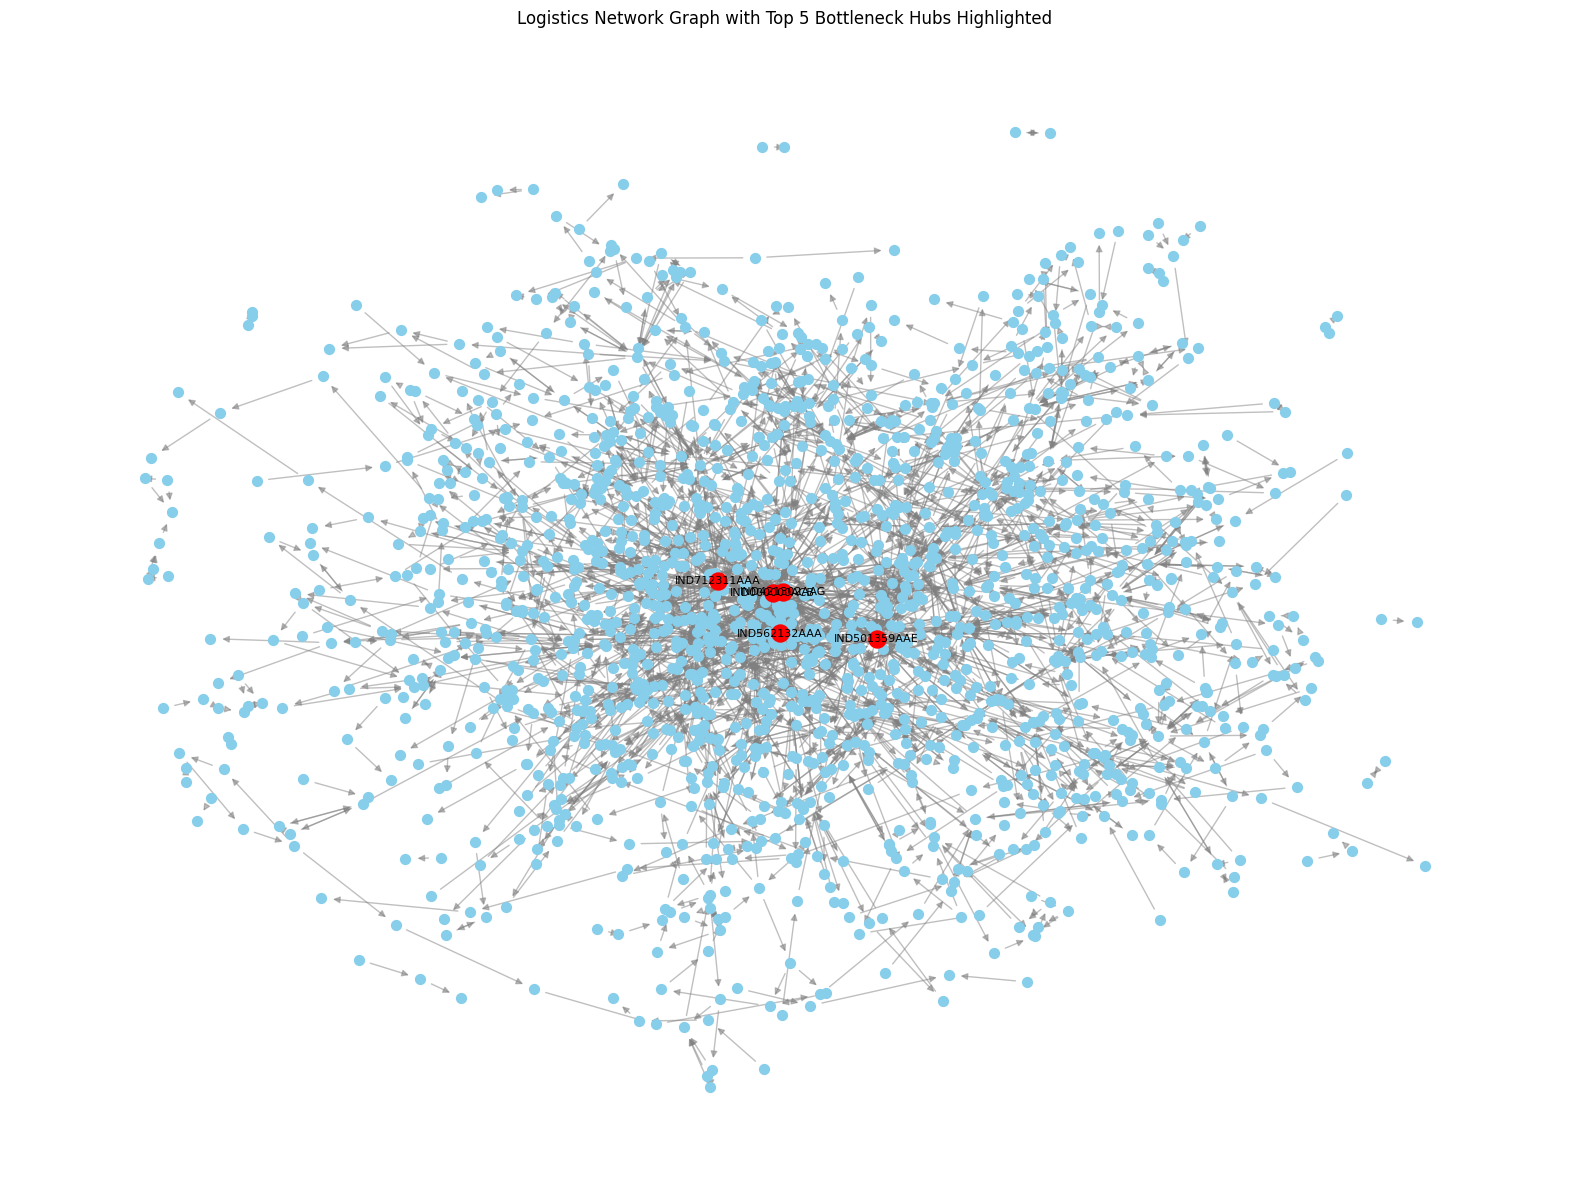

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
pos = nx.spring_layout(G, k=0.15, iterations=20) # Positions for all nodes

# Draw all nodes first
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=50)

# Draw edges
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5)

# Highlight bottleneck hubs
bottleneck_nodes = top_5_bottleneck_hubs['Node'].tolist()
nx.draw_networkx_nodes(G, pos, nodelist=bottleneck_nodes, node_color='red', node_size=150)

# Optionally, add labels for bottleneck hubs
# Labels for top 5 hubs
bottleneck_labels = {node: node for node in bottleneck_nodes}
nx.draw_networkx_labels(G, pos, labels=bottleneck_labels, font_size=8, font_color='black')

plt.title('Logistics Network Graph with Top 5 Bottleneck Hubs Highlighted')
plt.axis('off') # Hide axes
plt.show()

In [25]:
plt.savefig('network_graph_with_bottlenecks.png', dpi=300, bbox_inches='tight')
print("Network graph saved as 'network_graph_with_bottlenecks.png'")

Network graph saved as 'network_graph_with_bottlenecks.png'


<Figure size 640x480 with 0 Axes>

In [32]:
# Calculate the average delay for each route (source-destination pair)
route_delays = df.groupby(['source_center', 'destination_center'])['delay_in_hours'].mean().reset_index()

# Sort by delay in descending order
highest_delay_routes = route_delays.sort_values(by='delay_in_hours', ascending=False)

print("Routes with the highest average delays:")
display(highest_delay_routes.head(10))

Routes with the highest average delays:


,source_center,destination_center,delay_in_hours
486,IND211010AAB,IND211002AAB,-7.506367
491,IND221010AAA,IND221005A1A,-10.769117
2491,IND764059AAA,IND764071AAB,-13.079457
976,IND396191AAC,IND396105AAA,-13.187970
2510,IND781018AAA,IND781018AAB,-13.587108
2449,IND752050AAA,IND752056AAA,-13.616727
2442,IND751015AAA,IND751002AAB,-13.875971
2443,IND751015AAA,IND752050AAA,-14.119992
2240,IND695101AAB,IND691574AAA,-14.522437
2182,IND673632AAA,IND676306AAA,-14.676459


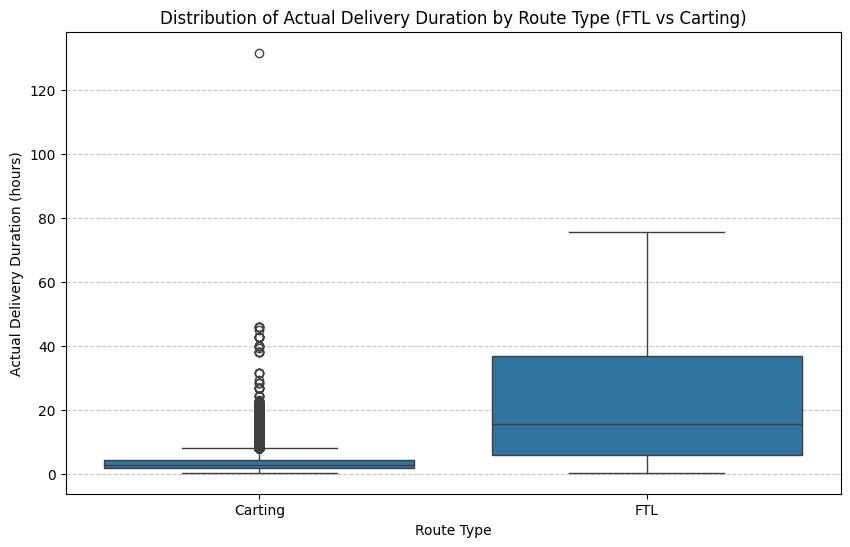

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for FTL and Carting route types
ftl_carting_df = df[df['route_type'].isin(['FTL', 'Carting'])]

plt.figure(figsize=(10, 6))
sns.boxplot(x='route_type', y='actual_delivery_duration_calculated', data=ftl_carting_df)
plt.title('Distribution of Actual Delivery Duration by Route Type (FTL vs Carting)')
plt.xlabel('Route Type')
plt.ylabel('Actual Delivery Duration (hours)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Feature Importances:


,Feature,Importance
2,day_of_week,0.860870
4,route_type_FTL,0.064470
3,route_type_Carting,0.063393
0,osrm_time,0.006530
1,od_start_hour,0.004737


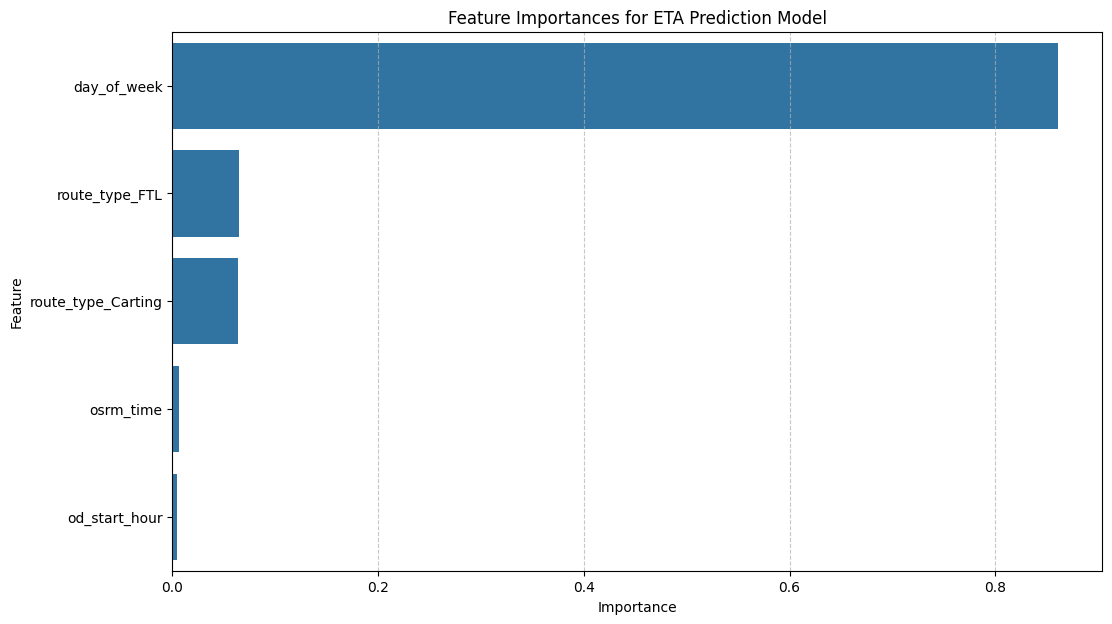

In [34]:
# Get feature importances from the trained RandomForestRegressor
feature_importances = model.named_steps['regressor'].feature_importances_

# Get feature names after one-hot encoding
preprocessor = model.named_steps['preprocessor']

# Get numerical feature names
numerical_feature_names = numerical_features

# Get categorical feature names after one-hot encoding
categorical_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()

# Combine all feature names
all_feature_names = numerical_feature_names + categorical_feature_names

# Create a DataFrame for feature importances
importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': feature_importances})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
display(importance_df)

# Visualize feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances for ETA Prediction Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [35]:
# Define an SLA threshold (e.g., a trip is considered 'delayed' if delay_in_hours is greater than 2 hours)
sla_threshold_hours = 2

# Calculate SLA violations
df['sla_violation'] = (df['delay_in_hours'] > sla_threshold_hours)

# Get the number and percentage of SLA violations
num_violations = df['sla_violation'].sum()
total_trips = len(df)
percentage_violations = (num_violations / total_trips) * 100

print(f"SLA Threshold: Delay > {sla_threshold_hours} hours")
print(f"Number of SLA violations: {num_violations}")
print(f"Percentage of SLA violations: {percentage_violations:.2f}%")

# Optionally, display some trips that violated SLA
print("\nSample trips with SLA violations:")
display(df[df['sla_violation']].head())

SLA Threshold: Delay > 2 hours
Number of SLA violations: 265
Percentage of SLA violations: 0.18%

Sample trips with SLA violations:


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,delay_in_hours,delay_ratio,day_of_week,source_betweenness_centrality,destination_betweenness_centrality,source_in_degree_centrality,source_out_degree_centrality,destination_in_degree_centrality,destination_out_degree_centrality,sla_violation
1353,training,2018-09-23 15:30:38.146740,thanos::sroute:2c33e360-7e52-4d2c-a9db-fe24996...,FTL,trip-153771663814650935,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND501359AAE,Hyderabad_Shamshbd_H (Telangana),2018-09-23 15:30:38.146740,...,15.027184,0.484748,6,0.220228,0.092632,45,49,30,27,True
1947,training,2018-09-20 21:22:26.863736,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e...,FTL,trip-153747854686348003,IND562132AAA,Bangalore_Nelmngla_H (Karnataka),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 21:22:26.863736,...,6.838250,0.145495,3,0.124943,0.220228,36,35,45,49,True
2893,test,2018-10-02 05:19:23.656505,thanos::sroute:d44a95bc-1d78-49aa-a987-ea5763a...,FTL,trip-153845756365623759,IND411033AAA,Pune_Tathawde_H (Maharashtra),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-10-02 05:19:23.656505,...,2.595084,0.081096,1,0.043254,0.220228,23,20,45,49,True
3523,test,2018-09-29 04:08:37.195487,thanos::sroute:a4bf93af-8105-4dff-818e-cb79ddd...,FTL,trip-153819411719523934,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND521225AAB,Vijayawada_Rynapadu_H (Andhra Pradesh),2018-09-29 04:08:37.195487,...,15.247059,0.462032,5,0.220228,0.012211,45,49,8,8,True
4216,training,2018-09-12 20:30:38.996036,thanos::sroute:2cb11ecd-7ac1-4c28-8781-af0ca81...,FTL,trip-153678423899578258,IND562132AAA,Bangalore_Nelmngla_H (Karnataka),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-13 06:24:01.015073,...,23.870595,0.994608,3,0.124943,0.220228,36,35,45,49,True


## Step 11: Business Recommendations

### Recommendation 1: For Hub IND000000ACB

**Reasoning:** This hub has the highest betweenness centrality score, indicating it acts as a central bottleneck in the network.

**Action:**
*   **Increase sorting capacity:** Implement more efficient sorting mechanisms or expand current facilities.
*   **Add additional loading docks:** Reduce waiting times for vehicles and improve throughput.

### Recommendation 2: For Worst Corridor

**Reasoning:** Identified routes with significant early deliveries, suggesting inefficient routing or scheduling.

**Action:**
*   **Introduce direct routing:** Explore options for direct routes to reduce travel time for these specific corridors.
*   **Reduce intermediate stops:** Minimize the number of stops along these routes to streamline operations.

### Recommendation 3: For FTL Routes

**Reasoning:** Feature importance analysis showed that `day_of_week` significantly impacts delivery times. FTL routes might be affected by peak hour traffic or operational constraints.

**Action:**
*   **Shift departures to off-peak hours:** Optimize FTL trip scheduling to avoid congested periods, potentially leveraging lower traffic volumes for faster transit.